In [ ]:
import cygnet as cy
import numpy as np
import uproot, gc, os
import imageio.v3 as iio
import matplotlib.pyplot as plt

# folders:
# raw_images
# redpixs

metric_test_path = "/home/frx/dataset/image_dataset/metric_test"

data_path = "/home/frx/dataset/root_dataset"

folders = os.listdir(data_path)
files_dict = {}

for fol in folders:
    sub_path = os.path.join(data_path, fol)
    files_dict[fol] = sorted(os.listdir(sub_path))

display(files_dict)

ufile_sample = uproot.open(data_path + "/" + fol + "/" + files_dict[fol][0])
tree = ufile_sample["event_info"]

n_classi = len(folders)
n_file = len(files_dict[fol])
n_eventi = len(tree["eventnumber"].arrays(library="np")["eventnumber"])

print(f"i see {n_classi} class folders each containing {n_file} files, each containing {n_eventi} events.")

i = 0
j = 0
k = 0

train = 0
vali = 0
test = 0

tot = n_classi * n_file * n_eventi
print(f"i see a total of {tot} events")
printable = []

ffol = folders[0]
fffile = files_dict[ffol][0]

dry_run = True
if not dry_run:
	for fol, files in files_dict.items():

		for j, ffile in enumerate(files):
			if j < 3:
				train_set = True
			else:
				train_set = False

			fpath = os.path.join(data_path, fol, ffile)
			with uproot.open(fpath) as ufile:
				tree = ufile["event_info"]
				redxs = tree["redpix_ix"].arrays(library="np")["redpix_ix"]
				redys = tree["redpix_iy"].arrays(library="np")["redpix_iy"]
				redzs = tree["redpix_iz"].arrays(library="np")["redpix_iz"]
				p_shape = ufile[f"pic_run{j+1}_ev{0}"].to_numpy()[0].shape

				for k in range(n_eventi):
					print(fol, ffile, train, vali, test)
					noisy = ufile[f"pic_run{j+1}_ev{k}"].to_numpy()[0].T
					xe = redxs[k]
					ye = redys[k]
					ze = redzs[k]
					redpixs = np.zeros(p_shape, dtype=np.uint16)
					redpixs[xe, ye] = ze
					redpixs = redpixs.T

					if train_set:
						train += 1

					else:
						if k < 100:
							vali += 1
						else:
							iio.imwrite(os.path.join(metric_test_path, "raw_images", f"raw_{test}.png"), noisy, extension=".png")
							iio.imwrite(os.path.join(metric_test_path, "redpixs", f"rp_{test}.png"), redpixs, extension=".png")
							test += 1

					noisy = None
					mask = None
					exp2_mask = None
					exp4_mask = None
					gc.collect()

				tree = None
				redxs = None
				redys = None
				redzs = None
				gc.collect()
else:
	print("dry!")

print()
print(f"N eventi: {tot}")
print(f"dataset split: {train} / {vali} / {test}")
print(f"o, in proporzione: {train/tot} / {vali/tot} / {test/tot}")

{'Acrylic_K40_TracceLunghe': ['histograms_Run00001_Quest2.root',
  'histograms_Run00002_Quest2.root',
  'histograms_Run00003_Quest2.root',
  'histograms_Run00004_Quest2.root'],
 'ER_50_keV': ['histograms_Run00001_Quest2.root',
  'histograms_Run00002_Quest2.root',
  'histograms_Run00003_Quest2.root',
  'histograms_Run00004_Quest2.root'],
 'He_5_keVee': ['histograms_Run00001_Quest2.root',
  'histograms_Run00002_Quest2.root',
  'histograms_Run00003_Quest2.root',
  'histograms_Run00004_Quest2.root'],
 'He_50_keVee': ['histograms_Run00001_Quest2.root',
  'histograms_Run00002_Quest2.root',
  'histograms_Run00003_Quest2.root',
  'histograms_Run00004_Quest2.root'],
 'He_15_keVee': ['histograms_Run00001_Quest2.root',
  'histograms_Run00002_Quest2.root',
  'histograms_Run00003_Quest2.root',
  'histograms_Run00004_Quest2.root'],
 'Cu_Th234_part2_TracceLunghe_Lowgain': ['histograms_Run00001.root',
  'histograms_Run00002.root',
  'histograms_Run00003.root',
  'histograms_Run00004.root'],
 'ER_1_keV

i see 9 class folders each containing 4 files, each containing 200 events.
i see a total of 7200 events
Acrylic_K40_TracceLunghe histograms_Run00001_Quest2.root 0 0 0
Acrylic_K40_TracceLunghe histograms_Run00001_Quest2.root 1 0 0
Acrylic_K40_TracceLunghe histograms_Run00001_Quest2.root 2 0 0
Acrylic_K40_TracceLunghe histograms_Run00001_Quest2.root 3 0 0
Acrylic_K40_TracceLunghe histograms_Run00001_Quest2.root 4 0 0
Acrylic_K40_TracceLunghe histograms_Run00001_Quest2.root 5 0 0
Acrylic_K40_TracceLunghe histograms_Run00001_Quest2.root 6 0 0
Acrylic_K40_TracceLunghe histograms_Run00001_Quest2.root 7 0 0
Acrylic_K40_TracceLunghe histograms_Run00001_Quest2.root 8 0 0
Acrylic_K40_TracceLunghe histograms_Run00001_Quest2.root 9 0 0
Acrylic_K40_TracceLunghe histograms_Run00001_Quest2.root 10 0 0
Acrylic_K40_TracceLunghe histograms_Run00001_Quest2.root 11 0 0
Acrylic_K40_TracceLunghe histograms_Run00001_Quest2.root 12 0 0
Acrylic_K40_TracceLunghe histograms_Run00001_Quest2.root 13 0 0
Acrylic_K4

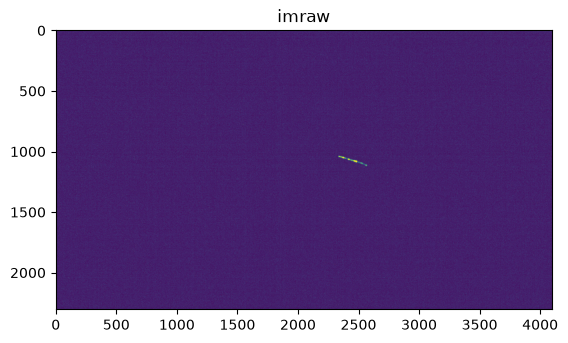

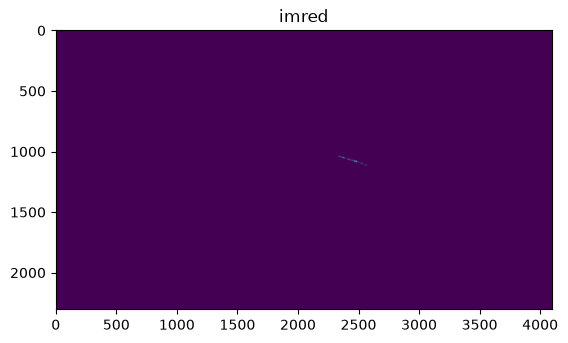

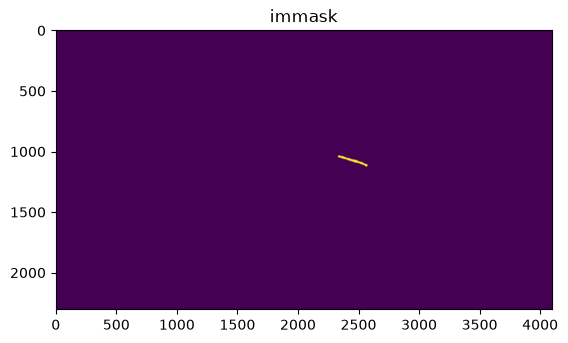

In [10]:
def quickplot(img, title="", vmax=220, vmin=198):
	plt.figure()
	plt.imshow(img, vmax=vmax, vmin=vmin)
	plt.title(title)
	plt.show()

idx = 0

imraw = iio.imread(os.path.join(metric_test_path, "raw_images", f"raw_{idx}.png"))
imred = iio.imread(os.path.join(metric_test_path, "redpixs", f"rp_{idx}.png"))
immask = (imred > 0)
quickplot(imraw, title="imraw")
quickplot(imred, "imred", None, None)
quickplot(immask, "immask", None, None)